<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Removing Duplicates**


Estimated time needed: **30** minutes


## Introduction


In this lab, you will focus on data wrangling, an important step in preparing data for analysis. Data wrangling involves cleaning and organizing data to make it suitable for analysis. One key task in this process is removing duplicate entries, which are repeated entries that can distort analysis and lead to inaccurate conclusions.  


## Objectives


In this lab you will perform the following:


1. Identify duplicate rows  in the dataset.
2. Use suitable techniques to remove duplicate rows and verify the removal.
3. Summarize how to handle missing values appropriately.
4. Use ConvertedCompYearly to normalize compensation data.
   


### Install the Required Libraries


In [34]:
!pip install pandas

### Step 1: Import Required Libraries


In [36]:
import pandas as pd

### Step 2: Load the Dataset into a DataFrame



load the dataset using pd.read_csv()


In [21]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

**Note: If you are working on a local Jupyter environment, you can use the URL directly in the <code>pandas.read_csv()</code>  function as shown below:**



In [ ]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv")

### Step 3: Identifying Duplicate Rows


**Task 1: Identify Duplicate Rows**
  1. Count the number of duplicate rows in the dataset.
  2. Display the first few duplicate rows to understand their structure.


In [22]:
## Write your code here
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Extract duplicate rows
duplicate_rows = df[df.duplicated()]

# Display first few duplicate rows
print("\nFirst few duplicate rows:")
print(duplicate_rows.head())

Number of duplicate rows: 10

First few duplicate rows:
       ResponseId                      MainBranch                 Age  \
65437           1  I am a developer by profession  Under 18 years old   
65438           2  I am a developer by profession     35-44 years old   
65439           3  I am a developer by profession     45-54 years old   
65440           4           I am learning to code     18-24 years old   
65441           5  I am a developer by profession     18-24 years old   

                Employment RemoteWork   Check  \
65437  Employed, full-time     Remote  Apples   
65438  Employed, full-time     Remote  Apples   
65439  Employed, full-time     Remote  Apples   
65440   Student, full-time        NaN  Apples   
65441   Student, full-time        NaN  Apples   

                                        CodingActivities  \
65437                                              Hobby   
65438  Hobby;Contribute to open-source projects;Other...   
65439  Hobby;Contribute to ope

### Step 4: Removing Duplicate Rows


**Task 2: Remove Duplicates**
   1. Remove duplicate rows from the dataset using the drop_duplicates() function.
2. Verify the removal by counting the number of duplicate rows after removal .


In [23]:
## Write your code here
df_clean = df.drop_duplicates()

# Step 2: Verify duplicates are removed
duplicate_count_after = df_clean.duplicated().sum()

print("Number of duplicate rows after removal:", duplicate_count_after)


Number of duplicate rows after removal: 0


### Step 5: Handling Missing Values


**Task 3: Identify and Handle Missing Values**
   1. Identify missing values for all columns in the dataset.
   2. Choose a column with significant missing values (e.g., EdLevel) and impute with the most frequent value.


In [24]:
## Write your code here
import numpy as np
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

Missing values per column:
ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10635
                       ...  
JobSatPoints_11        36001
SurveyLength            9257
SurveyEase              9201
ConvertedCompYearly    42012
JobSat                 36321
Length: 114, dtype: int64


In [25]:
#missing values in Edlevel
print("Missing values in EdLevel:", df['EdLevel'].isnull().sum())

# Get most frequent value
most_frequent = df['EdLevel'].mode()[0]

# Fill missing values
df['EdLevel']= df['EdLevel'].fillna(most_frequent)
print("Missing values in EdLevel after imputation:", df['EdLevel'].isnull().sum())

Missing values in EdLevel: 4653
Missing values in EdLevel after imputation: 0


### Step 6: Normalizing Compensation Data


**Task 4: Normalize Compensation Data Using ConvertedCompYearly**
   1. Use the ConvertedCompYearly column for compensation analysis as the normalized annual compensation is already provided.
   2. Check for missing values in ConvertedCompYearly and handle them if necessary.


In [14]:
## identifying missing compensation data
missing_comp = df['ConvertedCompYearly'].isnull().sum()
print("Missing values in ConvertedCompYearly:", missing_comp)
print(df['ConvertedCompYearly'].describe())


Missing values in ConvertedCompYearly: 42002
count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64


In [17]:
#handling missong conpensation data
median_comp = df['ConvertedCompYearly'].median()
df['ConvertedCompYearly']= df['ConvertedCompYearly'].fillna(median_comp)
print("Missing after handling:", df['ConvertedCompYearly'].isnull().sum())


Missing after handling: 0


### Step 7: Summary and Next Steps


**In this lab, you focused on identifying and removing duplicate rows.**

- You handled missing values by imputing the most frequent value in a chosen column.

- You used ConvertedCompYearly for compensation normalization and handled missing values.

- For further analysis, consider exploring other columns or visualizing the cleaned dataset.


In [ ]:
## Write your code here
!pip install matplotlib
import matplotlib.pyplot as plt

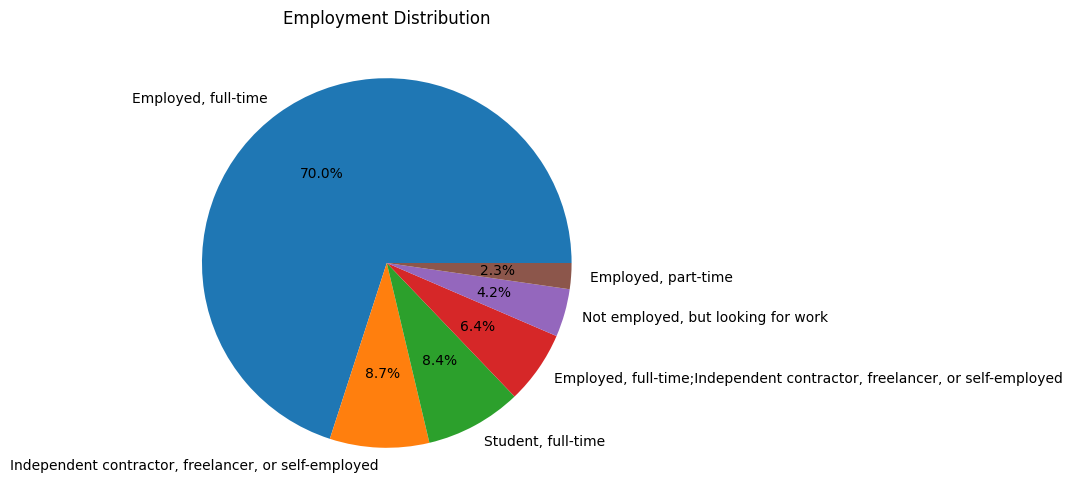

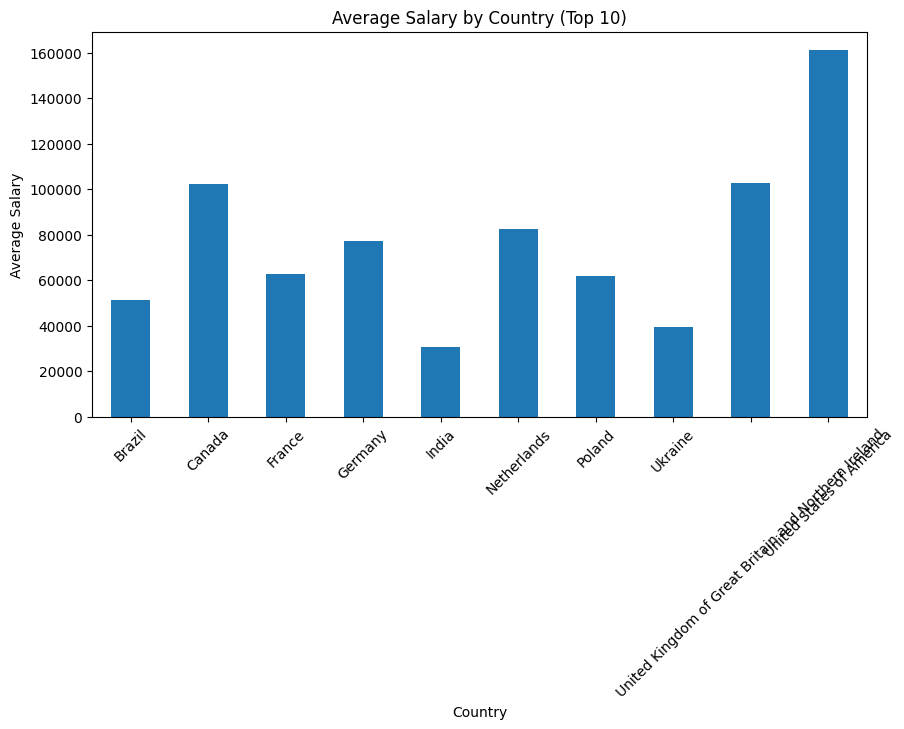

In [42]:
emp_counts = df_clean['Employment'].value_counts().head(6)

plt.figure(figsize=(6,6))
plt.pie(emp_counts, labels=emp_counts.index, autopct='%1.1f%%')
plt.title("Employment Distribution")
plt.show()

top_countries = df_clean['Country'].value_counts().head(10).index

country_salary = df_clean[df_clean['Country'].isin(top_countries)] \
    .groupby('Country')['ConvertedCompYearly'].mean()

country_salary.plot(kind='bar', figsize=(10,5))
plt.title("Average Salary by Country (Top 10)")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)
plt.show()

<!--
## Change Log

|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11-05|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|

--!>


Copyright © IBM Corporation. All rights reserved.
